In [4]:
import numpy as np
import time
import matplotlib.pyplot as plt

In [1]:
def alg1(data):
    data = list(data)
    changes = True
    while changes:
        changes = False
        for i in range(len(data) - 1):
            if data[i + 1] < data[i]:
                data[i], data[i + 1] = data[i + 1], data[i]
                changes = True
    return data


def alg2(data):
    if len(data) <= 1:
        return data
    else:
        split = len(data) // 2
        left = iter(alg2(data[:split]))
        right = iter(alg2(data[split:]))
        result = []
        left_top = next(left)
        right_top = next(right)
        while True:
            if left_top < right_top:
                result.append(left_top)
                try:
                    left_top = next(left)
                except StopIteration:
                    return result + [right_top] + list(right)
            else:
                result.append(right_top)
                try:
                    right_top = next(right)
                except StopIteration:
                    return result + [left_top] + list(left)

In [3]:
def data1(n, sigma=10, rho=28, beta=8 / 3, dt=0.01, x=1, y=1, z=1):
    state = np.array([x, y, z], dtype=float)
    result = []
    for _ in range(n):
        x, y, z = state
        state += dt * np.array(
            [sigma * (y - x), x * (rho - z) - y, x * y - beta * z]
        )
        result.append(float(state[0] + 30))
    return result


def data2(n):
    return list(range(n))


def data3(n):
    return list(range(n, 0, -1))


In [10]:
test_inputs = [
    [6, 8, 3, 1],
    [1, 2, 3, 4],
    [5, 4, 3, 2],
    [1, 1, 4, 2],
    [-7, 7, -2, 0],
    [],
    [9]
]

for test_data in test_inputs:
    result1 = alg1(test_data)
    result2 = alg2(test_data)

    assert result1 == sorted(test_data)
    assert result2 == sorted(test_data)

    print("Input:", test_data)
    print("alg1:", result1)
    print("alg2:", result2)
    print()

Input: [6, 8, 3, 1]
alg1: [1, 3, 6, 8]
alg2: [1, 3, 6, 8]

Input: [1, 2, 3, 4]
alg1: [1, 2, 3, 4]
alg2: [1, 2, 3, 4]

Input: [5, 4, 3, 2]
alg1: [2, 3, 4, 5]
alg2: [2, 3, 4, 5]

Input: [1, 1, 4, 2]
alg1: [1, 1, 2, 4]
alg2: [1, 1, 2, 4]

Input: [-7, 7, -2, 0]
alg1: [-7, -2, 0, 7]
alg2: [-7, -2, 0, 7]

Input: []
alg1: []
alg2: []

Input: [9]
alg1: [9]
alg2: [9]



In [6]:
def measure_runtime(function, test_data, repeats=5):
    expected = sorted(test_data)

    # test run
    assert function(test_data) == expected

    times = []

    for _ in range(repeats):
        start_time = time.perf_counter()
        result = function(test_data)
        end_time = time.perf_counter()

        times.append(end_time - start_time)

        assert result == expected

    return float(np.median(times))

In [7]:
n_values = np.unique(
    np.logspace(2, np.log10(4000), num=9).astype(int)
)

generators = {
    "data1": data1,
    "data2": data2,
    "data3": data3
}

benchmark_results = {}

for dataset_name, generator in generators.items():
    alg1_times = []
    alg2_times = []

    print(f"\nDataset: {dataset_name}")
    print(f"{'n':>6} {'alg1 (seconds)':>18} {'alg2 (seconds)':>18}")

    for n in n_values:
        # synthesis of data is not counted towards the whole time
        test_data = generator(int(n))

        time1 = measure_runtime(alg1, test_data)
        time2 = measure_runtime(alg2, test_data)

        alg1_times.append(time1)
        alg2_times.append(time2)

        print(f"{n:6d} {time1:18.8f} {time2:18.8f}")

    benchmark_results[dataset_name] = {
        "alg1": np.array(alg1_times),
        "alg2": np.array(alg2_times)
    }


Dataset: data1
     n     alg1 (seconds)     alg2 (seconds)
   100         0.00063387         0.00014293
   158         0.00162974         0.00023288
   251         0.00449074         0.00037776
   398         0.00798522         0.00061908
   632         0.02346608         0.00105332
  1002         0.10927843         0.00183558
  1590         0.47227793         0.00512736
  2522         0.62214184         0.00658705
  4000         1.60638452         0.00736443

Dataset: data2
     n     alg1 (seconds)     alg2 (seconds)
   100         0.00000549         0.00013041
   158         0.00000851         0.00024783
   251         0.00001303         0.00035641
   398         0.00002423         0.00066793
   632         0.00004167         0.00096034
  1002         0.00007084         0.00152215
  1590         0.00011360         0.00262220
  2522         0.00019210         0.00481433
  4000         0.00034374         0.00685513

Dataset: data3
     n     alg1 (seconds)     alg2 (seconds)
   100 

In [8]:
def estimate_slope(n_values, execution_times, last_k=5):
    log_n = np.log(n_values[-last_k:])
    log_time = np.log(execution_times[-last_k:])

    slope, intercept = np.polyfit(log_n, log_time, 1)

    return float(slope)


slopes = {}

for dataset_name, times in benchmark_results.items():
    slope1 = estimate_slope(n_values, times["alg1"])
    slope2 = estimate_slope(n_values, times["alg2"])

    slopes[dataset_name] = {
        "alg1": slope1,
        "alg2": slope2
    }

    print(
        f"{dataset_name}: "
        f"alg1 slope = {slope1:.3f}, "
        f"alg2 slope = {slope2:.3f}"
    )

data1: alg1 slope = 2.209, alg2 slope = 1.120
data2: alg1 slope = 1.131, alg2 slope = 1.102
data3: alg1 slope = 2.110, alg2 slope = 1.019


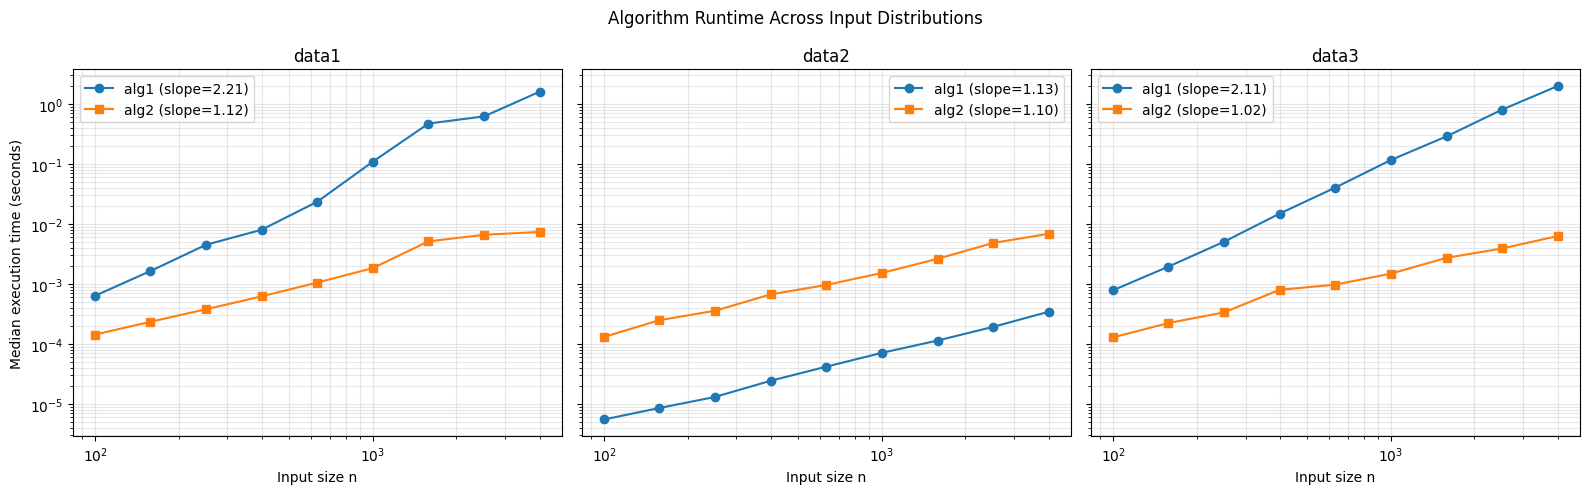

In [9]:
fig, axes = plt.subplots(
    1, 3,
    figsize=(16, 5),
    sharey=True
)

for ax, (dataset_name, times) in zip(
    axes, benchmark_results.items()
):
    slope1 = slopes[dataset_name]["alg1"]
    slope2 = slopes[dataset_name]["alg2"]

    ax.loglog(
        n_values,
        times["alg1"],
        marker="o",
        label=f"alg1 (slope={slope1:.2f})"
    )

    ax.loglog(
        n_values,
        times["alg2"],
        marker="s",
        label=f"alg2 (slope={slope2:.2f})"
    )

    ax.set_title(dataset_name)
    ax.set_xlabel("Input size n")
    ax.grid(True, which="both", alpha=0.3)
    ax.legend()

axes[0].set_ylabel("Median execution time (seconds)")

fig.suptitle("Algorithm Runtime Across Input Distributions")
plt.tight_layout()
plt.show()